# WIMP Spectrum approximation
We use the classical (no spin, form factor = 1) cross section computation and approximate the limits of Ge detectors in LEGEND

## Imports

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from scipy.integrate import quad

## Implement basic formulas

In [2]:
dRdE_int = lambda prefactor, v_min, f_adj: prefactor * quad(f_adj, v_min, np.inf)[0]

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import numpy as np

def make_eta(f1, v_max, n_points=10000):

    v = np.linspace(1e-10, v_max, n_points)

    integrand = f1(v) / v

    eta_grid = -cumulative_trapezoid(
        integrand[::-1],
        v[::-1],
        initial=0
    )[::-1]

    return interp1d(v, eta_grid, bounds_error=False, fill_value=0.0)


def dRdE(m, m_n, E, sigma, rho, eta):
    mu = m * m_n / (m + m_n)
    prefactor = rho * sigma / (m * 2 * mu**2)
    E = np.asarray(E)

    v_min = np.sqrt(m_n * E / (2 * mu**2))
    return prefactor * eta(v_min)

def dRdE_grid(m, m_n, E, sigma, rho, eta):
    m = np.asarray(m)[:, None]      # shape (Nm,1)
    E = np.asarray(E)[None, :]      # shape (1,NE)

    mu = m * m_n / (m + m_n)
    prefactor = rho * sigma / (m * 2 * mu**2)

    v_min = np.sqrt(m_n * E / (2 * mu**2))
    return prefactor * eta(v_min)

In [3]:
# Use Boltzmann
from scipy.special import erf

def normalization(v0, vesc):
    z = vesc / v0
    return np.pi**1.5 * v0**3 * (
        erf(z) - (2/np.sqrt(np.pi))*z*np.exp(-z**2)
    )

def eta_analytical(v_min, v0, vesc):
    N = abs(normalization(v0, vesc))
    val = (2 * np.pi * v0**2 / N) * (np.exp(-(v_min/v0)**2) - np.exp(-(vesc/v0)**2))
    return np.where(v_min < vesc, val, 0.0)

# Galactic frame
def speed_f(v0, vesc):
    N = abs(normalization(v0, vesc))
    return lambda v: 4*np.pi*v**2 * np.exp(-(v/v0)**2)/ N * np.heaviside(vesc - v, 0.5)

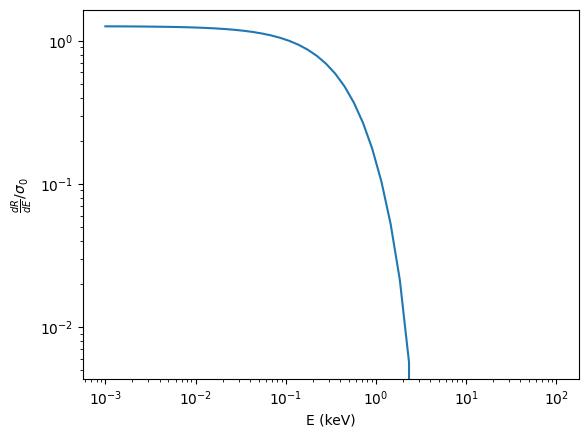

In [30]:
# Parameters
from scipy.constants import *

# Natural units
GeV = 1.0

vesc= 544e3 / c
v0= 220e3 / c
m_n = 76 * 0.9315   # GeV
m = 6             # GeV
rho = 0.3           # GeV / cm^3


eta = make_eta(speed_f(v0, vesc), vesc)

E_keV = np.logspace(-3, 2)  # 0.1 keV to 100 keV
E = E_keV * 1e-6  # GeV

plt.plot(E_keV, np.abs(dRdE(m, m_n, E, 1, rho, eta)))
plt.xscale('log')
plt.yscale('log')
plt.xlabel("E (keV)")
plt.ylabel(r"$\frac{dR}{dE} / \sigma_0$")
plt.show()

## Solar frame
This should be pretty accurate, since modulation is not of interest to us. We could use the effective speed $\langle v_{Sun} + \cos{\delta}\,  v_{Earth}\rangle$, where $\delta \approx 60^\circ$ is the angle between the movement of the sun and the ecliptic plane. 

In [31]:
# Constants
v_sun = 251e3 / c
v_earth = 30e3 / c
v_eff = v_sun + np.cos(np.pi/3) * v_earth

In [32]:
def speed_f_boosted(v0, vesc, ve):
    N = abs(normalization(v0, vesc))
    prefactor = np.pi * v0**2 / (ve * N)
    
    def g(v):
        v = np.asarray(v)
        res = np.zeros_like(v)
        
        # Region 1: v < vesc - ve
        mask1 = v < (vesc - ve)
        res[mask1] = v[mask1] * prefactor * (
            np.exp(-((v[mask1] - ve)/v0)**2) - np.exp(-((v[mask1] + ve)/v0)**2)
        )
        
        # Region 2: vesc - ve <= v < vesc + ve
        mask2 = (v >= (vesc - ve)) & (v < (vesc + ve))
        res[mask2] = v[mask2] * prefactor * (
            np.exp(-((v[mask2] - ve)/v0)**2) - np.exp(-(vesc/v0)**2)
        )
        
        # Region 3: v >= vesc + ve (remains 0)
        return res
        
    return g

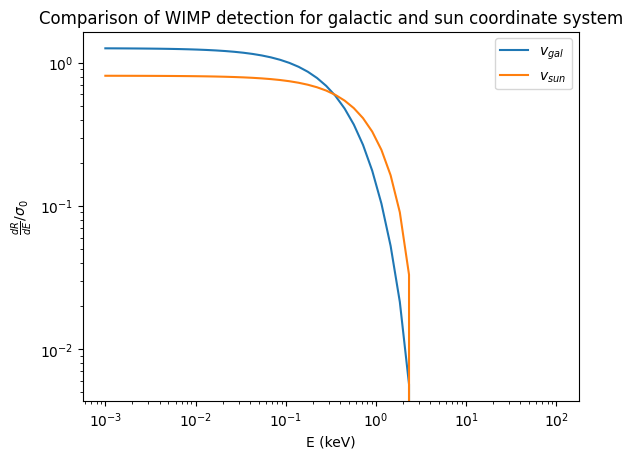

In [33]:
E = E_keV * 1e-6  # GeV
eta_sun = make_eta(speed_f_boosted(v0, vesc, v_eff), vesc)
eta_gal = make_eta(speed_f(v0, vesc), vesc)

plt.plot(E_keV, np.abs(dRdE(m, m_n, E, 1, rho, eta_gal)), label=r"$v_{gal}$")
plt.plot(E_keV, np.abs(dRdE(m, m_n, E, 1, rho, eta_sun)), label=r"$v_{sun}$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("E (keV)")
plt.ylabel(r"$\frac{dR}{dE} / \sigma_0$")
plt.title("Comparison of WIMP detection for galactic and sun coordinate system")
plt.legend()
plt.show()

## Form Factors

In [34]:
# Built on C code

def get_b2_parameter(A):
    """
    Computes the harmonic oscillator parameter squared (b^2) in GeV^-2
    following the standard parametrization from the DMFormFactor package.
    """
    # b in units of fm
    b_fm = np.sqrt(41.467 / (45.0 * A**(-1/3) - 25.0 * A**(-2/3)))
    # Convert from fm to GeV^-1 using hbar*c ≈ 0.1973 GeV*fm
    b_gev = b_fm / 0.1973
    return b_gev**2

def f_polynomial(Er, A, Z, coeffs):
    """
    Evaluates the NREFT form factor polynomial: exp(-2w) * sum(a_i * w^i)
    """
    mn = Z * 0.938 + (A - Z) * 0.940  # Nuclear mass in GeV
    q2 = 2.0 * mn * (Er * 1e-6)       # Momentum transfer squared in GeV^2
    
    b2 = get_b2_parameter(A)
    w = 0.25 * q2 * b2
    
    # Evaluate polynomial sum(a_i * w^i)
    poly = np.zeros_like(Er, dtype=float)
    for power, coeff in enumerate(coeffs):
        poly += coeff * (w**power)
        
    return np.exp(-2.0 * w) * poly

def F2_SI_Ge76(Er):
    """
    Standard Spin-Independent Form Factor squared for Ge-76,
    normalized to 1.0 at Er = 0.
    """
    Er = np.asarray(Er)
    A = 76
    Z = 32
    
    # Coefficients from the C-code for ("M", "M")
    coeffs_pp = [1024., -2800., 2900., -1400., 340., -40., 1.8, -0.0024, 0., 0., 0.]
    coeffs_nn = [1936., -6300., 7800., -4700., 1500., -260., 21., -0.66, 0.0069, 0., 0.]
    coeffs_pn = [1408., -4200., 4800., -2600., 730., -100., 6.5, -0.11, 0., 0., 0.]
    
    ff_pp = f_polynomial(Er, A, Z, coeffs_pp)
    ff_nn = f_polynomial(Er, A, Z, coeffs_nn)
    ff_pn = f_polynomial(Er, A, Z, coeffs_pn)
    
    # Under standard SI, we assume equal coupling to protons and neutrons.
    # Total sum at Er=0 is (Z + (A-Z))^2 = A^2 = 76^2 = 5776.
    total_unnormalized = ff_pp + 2.0 * ff_pn + ff_nn
    
    return total_unnormalized / (A**2)

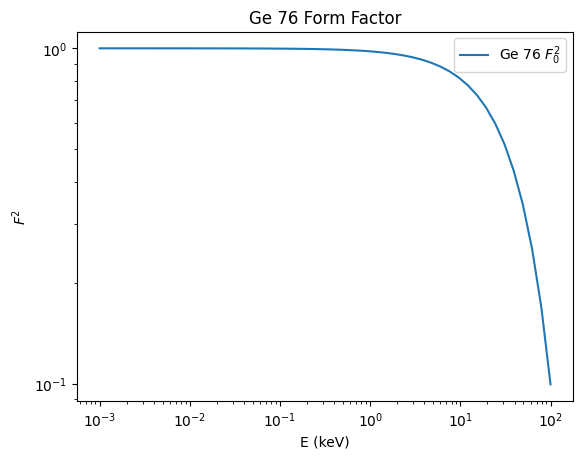

In [35]:
F2 = F2_SI_Ge76(E_keV)

plt.plot(E_keV, F2, label=r"Ge 76 $F_0^2$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("E (keV)")
plt.ylabel(r"$F^2$")
plt.title("Ge 76 Form Factor")
plt.legend()
plt.show()

We can see that the form factor effects are only dominant for large WIMP masses (~100 GeV). For small WIMP masses, the velocity distribution is much more important to the scaling.

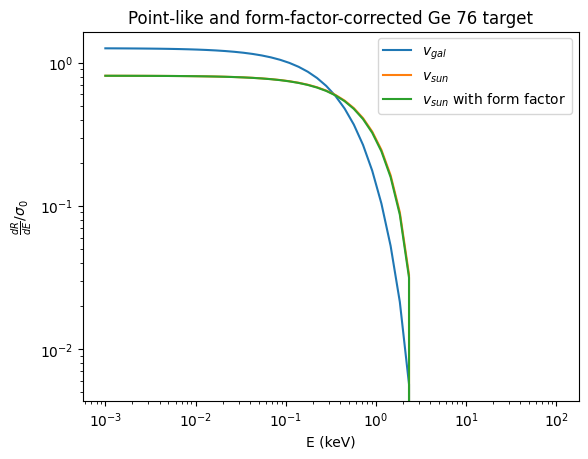

In [38]:
E = E_keV * 1e-6  # GeV
eta_sun = make_eta(speed_f_boosted(v0, vesc, v_eff), vesc, n_points=int(1e5))
eta_gal = make_eta(speed_f(v0, vesc), vesc, n_points=int(1e5))

plt.plot(E_keV, np.abs(dRdE(m, m_n, E, 1, rho, eta_gal)), label=r"$v_{gal}$")
plt.plot(E_keV, np.abs(dRdE(m, m_n, E, 1, rho, eta_sun)), label=r"$v_{sun}$")
plt.plot(E_keV, np.abs(dRdE(m, m_n, E, 1, rho, eta_sun))*F2, label=r"$v_{sun}$ with form factor")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("E (keV)")
plt.ylabel(r"$\frac{dR}{dE} / \sigma_0$")
plt.title("Point-like and form-factor-corrected Ge 76 target")
plt.legend()
plt.show()